<a href="https://colab.research.google.com/github/manju652/AI-Chatbot/blob/main/Student_attendence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PROJECT TITLE:Student Attendance Analysis and Engagement Prediction Using Machine Learning




### Problem Statement

Educational institutions often maintain attendance records manually or through online meeting platforms. However, simply recording attendance does not provide meaningful insights into student participation and engagement. Faculty members face challenges in identifying students with low attendance, irregular participation, and poor engagement levels in online sessions.

This project aims to analyze student attendance data collected from online classes and apply machine learning techniques to classify student engagement levels based on attendance duration and participation metrics. The system helps identify attendance patterns, monitor student involvement, and support early intervention for students who may be at risk of low academic participation.

### Objectives

* To analyze student attendance records from online sessions.
* To perform Exploratory Data Analysis (EDA) on attendance data.
* To classify students into different engagement levels (High, Medium, Low).
* To build a machine learning model for predicting student engagement.
* To visualize attendance trends and participation patterns.
* To assist educators in monitoring and improving student attendance.

### Expected Outcome

The system will generate attendance insights, engagement classifications, visual reports, and predictive results that help educational institutions make data-driven decisions regarding student participation and attendance management.

You can put this as the **Introduction / Problem Statement** section at the beginning of your notebook and project report.


# 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

2. Load Dataset

In [7]:
df = pd.read_csv("student attendence.csv")

df.head()

,Topic,Type,ID,Host name,Host email,Start time,End time,Participants,Duration (minutes),Total participant minutes,...,Max concurrent views,Creation time,Name (original name),Email,Join time,Leave time,Duration (minutes).1,Guest,Recording disclaimer response,In waiting room
0,Data Analysis using Python - Summer Online Int...,Meeting,932 5001 3841,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:52:14 PM,05/30/2026 05:52:23 PM,1,1,1,...,-,05/05/2026 11:06:38 AM,santosh s (Host),venkatasivasantosh.s@apssdc.in,05/30/2026 05:52:14 PM,05/30/2026 05:52:23 PM,1,No,NaN,No
1,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,Jaya Prakash Jagadam,jayaprakashjagadam7@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:10:28 PM,68,Yes,No Response,No
2,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,Shreshta K 25BFD58007 SVCE,shreshtasudhakar@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 06:10:57 PM,8,Yes,No Response,No
3,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,Ravilla Jeshitha,jeshitharavillajeshitha@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:50:44 PM,108,Yes,OK,No
4,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,ABHIRAM-24B91A0345-SRKR ( JONNALAGADDA ABHIRAM ),jonnalagadda.abhiram2007@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:48:28 PM,106,Yes,OK,No


# 3. Understanding the Dataset

In [8]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4399, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4399 entries, 0 to 4398
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Topic                          4399 non-null   object 
 1   Type                           4399 non-null   object 
 2   ID                             4399 non-null   object 
 3   Host name                      4399 non-null   object 
 4   Host email                     4399 non-null   object 
 5   Start time                     4399 non-null   object 
 6   End time                       4399 non-null   object 
 7   Participants                   4399 non-null   int64  
 8   Duration (minutes)             4399 non-null   int64  
 9   Total participant minutes      4399 non-null   int64  
 10  Department                     4399 non-null   object 
 11  Group                          0 non-null      float64
 12  Source             

In [9]:
df.columns

Index(['Topic', 'Type', 'ID', 'Host name', 'Host email', 'Start time',
       'End time', 'Participants', 'Duration (minutes)',
       'Total participant minutes', 'Department', 'Group', 'Source',
       'Unique viewers', 'Max concurrent views', 'Creation time',
       'Name (original name)', 'Email', 'Join time', 'Leave time',
       'Duration (minutes).1', 'Guest', 'Recording disclaimer response',
       'In waiting room'],
      dtype='object')

In [10]:
df.describe()

,Participants,Duration (minutes),Total participant minutes,Group,Duration (minutes).1
count,4399.000000,4399.000000,4399.000000,0.0,4399.000000
mean,1485.963401,102.494885,42540.192998,NaN,26.274608
std,683.517932,29.392042,25743.621853,NaN,30.492547
min,1.000000,1.000000,1.000000,NaN,0.000000
25%,826.000000,75.000000,18585.000000,NaN,4.000000
50%,1008.000000,113.000000,22124.000000,NaN,13.000000
75%,2163.000000,122.000000,68311.000000,NaN,39.000000
max,2163.000000,122.000000,68311.000000,NaN,120.000000


# 4. Data Cleaning

In [11]:
df.isnull().sum()

,0
Topic,0
Type,0
ID,0
Host name,0
Host email,0
Start time,0
End time,0
Participants,0
Duration (minutes),0
Total participant minutes,0


Remove Empty Column

In [16]:
df.drop(columns=['Group'], inplace=True, errors='ignore')
df.drop(columns=['Recording disclaimer response'], inplace=True)

Remove Duplicates

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.isnull().sum()

,0
Topic,0
Type,0
ID,0
Host name,0
Host email,0
Start time,0
End time,0
Participants,0
Duration (minutes),0
Total participant minutes,0


# 5. Exploratory Data Analysis (EDA)

Attendance Duration Distribution

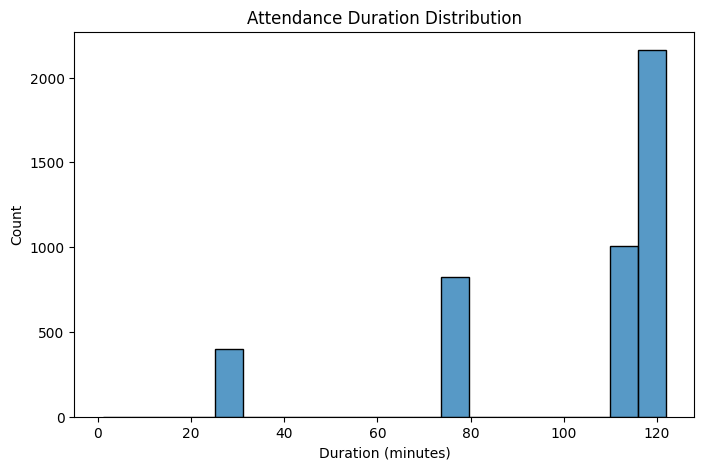

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Duration (minutes)'], bins=20)

plt.title("Attendance Duration Distribution")
plt.show()

Department Distribution

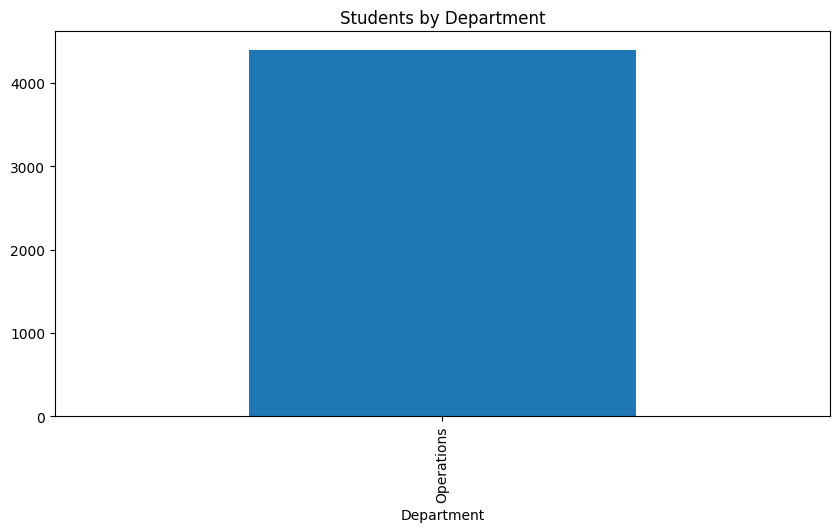

In [20]:
plt.figure(figsize=(10,5))

df['Department'].value_counts().plot(kind='bar')

plt.title("Students by Department")
plt.show()

Top 10 Attendance Durations

In [23]:
top_students = df.nlargest(10, 'Duration (minutes)')

top_students[['Name (original name)', 'Duration (minutes)']]

,Name (original name),Duration (minutes)
1,Jaya Prakash Jagadam,122
2,Shreshta K 25BFD58007 SVCE,122
3,Ravilla Jeshitha,122
4,ABHIRAM-24B91A0345-SRKR ( JONNALAGADDA ABHIRAM ),122
5,244M5A0502...Bandi Lokanath vemu it,122
6,23HP1A05C3 RACHAGULLA SUJITH,122
7,24bq1a42i7 M.Siva balaji VVIT ( Siva balaji Ma...,122
8,GULLAPALLI HARSHINI- 23HP1A4207-ALIET,122
9,Thummuri Srujana,122
10,Nallam Usha Rani-234M1A05A7 Vemu Institute of ...,122


# 6. Feature Engineering

In [25]:
def engagement(duration):

    if duration >= 60:
        return "High"

    elif duration >= 30:
        return "Medium"

    else:
        return "Low"

df['Engagement'] = df['Duration (minutes)'].apply(engagement)

In [27]:
df[['Duration (minutes)', 'Engagement']].head()

,Duration (minutes),Engagement
0,1,Low
1,122,High
2,122,High
3,122,High
4,122,High


# 7. Visualization of Engagement Levels

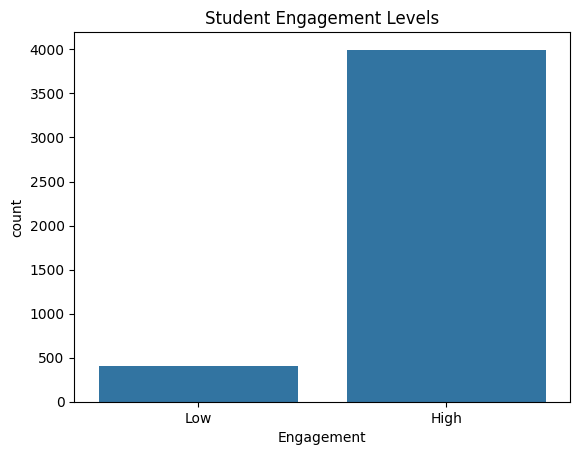

In [28]:
sns.countplot(x='Engagement', data=df)

plt.title("Student Engagement Levels")
plt.show()

# 8. Data Preprocessing

Convert Labels into Numbers

In [29]:
le = LabelEncoder()

df['Engagement'] = le.fit_transform(df['Engagement'])

Encode Department

In [30]:
dept_encoder = LabelEncoder()

df['Department'] = dept_encoder.fit_transform(
    df['Department']
)

# 9. Feature Selection

In [32]:
X = df[
    ['Duration (minutes)',
     'Participants',
     'Total participant minutes',
     'Department']
]

y = df['Engagement']

# 10. Split Dataset

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 11. Model Building

In [34]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

12. Model Prediction

In [36]:
predictions = model.predict(X_test)

# 13. Model Evaluation

In [37]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [38]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00        80

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880



# 14. Feature Importance

In [39]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,Participants,0.37
2,Total participant minutes,0.32
0,Duration (minutes),0.31
3,Department,0.00


# 15. Conclusion



This project successfully analyzed student attendance data collected from online sessions. Data cleaning and exploratory data analysis were performed to understand attendance behavior. Student engagement levels were created based on attendance duration and machine learning techniques were applied to predict engagement levels. The Random Forest model achieved high prediction performance and identified the key factors influencing student participation. The system can help educational institutions monitor attendance and improve student engagement.

# Future Scope

Real-time attendance monitoring.
Integration with online learning platforms.
Early warning system for low-attendance students.
Attendance trend forecasting using advanced machine learning models.
Interactive dashboard for faculty and administrators.